This is the notebook to show the implementation of score-based generative model with SDE (2nd part of the tutorial). In this case, we will sample the training data from the swiss roll distribution like the previous part.
From the training data, we will try to learn how to draw new samples from the swiss roll distribution with Score-based Generative Model (SGM)

In [1]:
import torch
import torchvision
from torch.utils.data import Subset
import numpy as np
import pandas as pd

# generate the MNIST dataset
transforms = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
])
mnist_dset = torchvision.datasets.MNIST("mnist", download=True, transform=transforms)
print(mnist_dset[0][0].shape)

torch.Size([1, 28, 28])


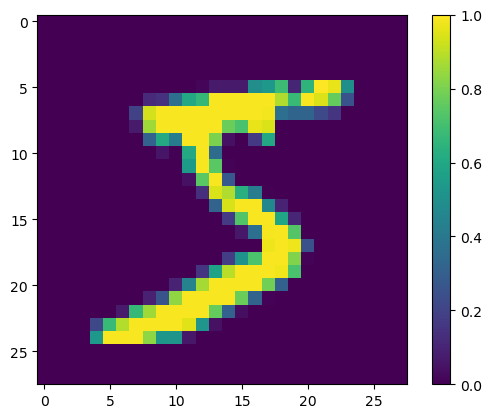

In [2]:
# show a sample
import matplotlib.pyplot as plt
# the first index is for the dataset, the second is for the tuple, the third one is for channel
plt.imshow(mnist_dset[0][0][0])
plt.colorbar()

The neural network to learn the score function is a U-Net architecture that accepts the image + the time and produce the score function with the same shape as the image.

In [3]:
class ScoreNetwork0(torch.nn.Module):
    # takes an input image and time, returns the score function
    def __init__(self):
        super().__init__()
        nch = 2
        chs = [32, 64, 128, 256, 256]
        self._convs = torch.nn.ModuleList([
            torch.nn.Sequential(
                torch.nn.Conv2d(2, chs[0], kernel_size=3, padding=1),  # (batch, ch, 28, 28)
                torch.nn.LogSigmoid(),  # (batch, 8, 28, 28)
            ),
            torch.nn.Sequential(
                torch.nn.MaxPool2d(kernel_size=2, stride=2),  # (batch, ch, 14, 14)
                torch.nn.Conv2d(chs[0], chs[1], kernel_size=3, padding=1),  # (batch, ch, 14, 14)
                torch.nn.LogSigmoid(),  # (batch, 16, 14, 14)
            ),
            torch.nn.Sequential(
                torch.nn.MaxPool2d(kernel_size=2, stride=2),  # (batch, ch, 7, 7)
                torch.nn.Conv2d(chs[1], chs[2], kernel_size=3, padding=1),  # (batch, ch, 7, 7)
                torch.nn.LogSigmoid(),  # (batch, 32, 7, 7)
            ),
            torch.nn.Sequential(
                torch.nn.MaxPool2d(kernel_size=2, stride=2, padding=1),  # (batch, ch, 4, 4)
                torch.nn.Conv2d(chs[2], chs[3], kernel_size=3, padding=1),  # (batch, ch, 4, 4)
                torch.nn.LogSigmoid(),  # (batch, 64, 4, 4)
            ),
            torch.nn.Sequential(
                torch.nn.MaxPool2d(kernel_size=2, stride=2),  # (batch, ch, 2, 2)
                torch.nn.Conv2d(chs[3], chs[4], kernel_size=3, padding=1),  # (batch, ch, 2, 2)
                torch.nn.LogSigmoid(),  # (batch, 64, 2, 2)
            ),
        ])
        self._tconvs = torch.nn.ModuleList([
            torch.nn.Sequential(
                # input is the output of convs[4]
                torch.nn.ConvTranspose2d(chs[4], chs[3], kernel_size=3, stride=2, padding=1, output_padding=1),  # (batch, 64, 4, 4)
                torch.nn.LogSigmoid(),
            ),
            torch.nn.Sequential(
                # input is the output from the above sequential concated with the output from convs[3]
                torch.nn.ConvTranspose2d(chs[3] * 2, chs[2], kernel_size=3, stride=2, padding=1, output_padding=0),  # (batch, 32, 7, 7)
                torch.nn.LogSigmoid(),
            ),
            torch.nn.Sequential(
                # input is the output from the above sequential concated with the output from convs[2]
                torch.nn.ConvTranspose2d(chs[2] * 2, chs[1], kernel_size=3, stride=2, padding=1, output_padding=1),  # (batch, chs[2], 14, 14)
                torch.nn.LogSigmoid(),
            ),
            torch.nn.Sequential(
                # input is the output from the above sequential concated with the output from convs[1]
                torch.nn.ConvTranspose2d(chs[1] * 2, chs[0], kernel_size=3, stride=2, padding=1, output_padding=1),  # (batch, chs[1], 28, 28)
                torch.nn.LogSigmoid(),
            ),
            torch.nn.Sequential(
                # input is the output from the above sequential concated with the output from convs[0]
                torch.nn.Conv2d(chs[0] * 2, chs[0], kernel_size=3, padding=1),  # (batch, chs[0], 28, 28)
                torch.nn.LogSigmoid(),
                torch.nn.Conv2d(chs[0], 1, kernel_size=3, padding=1),  # (batch, 1, 28, 28)
            ),
        ])

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        # x: (..., ch0 * 28 * 28), t: (..., 1)
        x2 = torch.reshape(x, (*x.shape[:-1], 1, 28, 28))  # (..., ch0, 28, 28)
        tt = t[..., None, None].expand(*t.shape[:-1], 1, 28, 28)  # (..., 1, 28, 28)
        x2t = torch.cat((x2, tt), dim=-3)
        signal = x2t
        signals = []
        for i, conv in enumerate(self._convs):
            signal = conv(signal)
            if i < len(self._convs) - 1:
                signals.append(signal)

        for i, tconv in enumerate(self._tconvs):
            if i == 0:
                signal = tconv(signal)
            else:
                signal = torch.cat((signal, signals[-i]), dim=-3)
                signal = tconv(signal)
        signal = torch.reshape(signal, (*signal.shape[:-3], -1))  # (..., 1 * 28 * 28)
        return signal

score_network = ScoreNetwork0()

Now let's implement the denoising score matching function below (same as before),
$$\begin{equation}
\mathcal{L}(\theta) = \int_0^1\lambda (t) \mathbb{E}_{\mathbf{x}(0)}\mathbb{E}_{\mathbf{x}(t)|\mathbf{x}(0)}\left[\left\lVert\mathbf{s}(\mathbf{x}(t), t; \theta) - \nabla_{\mathbf{x}(0)}\mathrm{log}\ p(\mathbf{x}(t)|\mathbf{x}(0))\right\rVert^2\right]\ dt
\end{equation}$$
where $\lambda(t) = 1 - \mathrm{exp}\left[-\int_0^t \beta(s) ds\right]$ and $\nabla_{\mathbf{x}(0)}\mathrm{log}\ p(\mathbf{x}(t)|\mathbf{x}(0))$ can be calculated analytically,
$$\begin{align}
\nabla_{\mathbf{x}(0)}\mathrm{log}\ p(\mathbf{x}(t)|\mathbf{x}(0)) &= -\frac{\mathbf{x}(t) - \boldsymbol{\mu}(t)}{\sigma^2(t)} \\
\boldsymbol{\mu}(t) &= \mathbf{x}(0)\mathrm{exp}\left[-\frac{1}{2}\int_0^t \beta(s) ds\right] \\
\sigma^2(t) &= 1 - \mathrm{exp}\left[-\int_0^t \beta(s) ds\right]
\end{align}$$
with $\beta(t) = 0.1 + (20 - 0.1) t$.

In [4]:
def calc_loss(score_network: torch.nn.Module, x: torch.Tensor) -> torch.Tensor:
    # x: (batch_size, nch) is the training data

    # sample the time
    t = torch.rand((x.shape[0], 1), dtype=x.dtype, device=x.device) * (1 - 1e-4) + 1e-4

    # calculate the terms for the posterior log distribution
    int_beta = (0.1 + 0.5 * (20 - 0.1) * t) * t  # integral of beta
    mu_t = x * torch.exp(-0.5 * int_beta)
    var_t = -torch.expm1(-int_beta)
    x_t = torch.randn_like(x) * var_t ** 0.5 + mu_t
    grad_log_p = -(x_t - mu_t) / var_t  # (batch_size, nch)

    # calculate the score function
    score = score_network(x_t, t)  # score: (batch_size, nch)

    # calculate the loss function
    loss = (score - grad_log_p) ** 2
    lmbda_t = var_t
    weighted_loss = lmbda_t * loss
    return torch.mean(weighted_loss)


Everything is ready, now we can start the training. We use batch size 64 with about 400 epochs. Please be aware that the training could take about 2 hours with a GPU (NVIDIA T4).

In [5]:

targets = mnist_dset.targets

zero_idx = (targets == 0).nonzero(as_tuple=True)[0]
nonzero_idx = (targets != 0).nonzero(as_tuple=True)[0]

mnist_zeros = Subset(mnist_dset, zero_idx)
mnist_nonzeros = Subset(mnist_dset, nonzero_idx)

In [6]:
# start the training loop
import time
opt = torch.optim.Adam(score_network.parameters(), lr=3e-4)
#dloader = torch.utils.data.DataLoader(mnist_dset, batch_size=64, shuffle=True)
dloader = torch.utils.data.DataLoader(mnist_zeros, batch_size=64, shuffle=True)

# Use CUDA if available, otherwise use CPU
if torch.cuda.is_available():
    device = torch.device('cuda:0')
    print("Using GPU (CUDA)")
else:
    device = torch.device('cpu')
    print("⚠️  CUDA not available. Using CPU (training will be slower)")
    print("   For GPU training, ensure PyTorch is installed with CUDA support")

score_network = score_network.to(device)
t0 = time.time()
for i_epoch in range(400):
    total_loss = 0
    for data, _ in dloader:  # we don't need the data class
        data = data.reshape(data.shape[0], -1).to(device)
        opt.zero_grad()

        # training step
        loss = calc_loss(score_network, data)
        loss.backward()
        opt.step()

        # running stats
        total_loss = total_loss + loss.detach().item() * data.shape[0]

    # print the training stats
    if i_epoch % 20 == 0:
        print(f"{i_epoch} ({time.time() - t0}s): {total_loss / len(mnist_dset)}")

⚠️  CUDA not available. Using CPU (training will be slower)
   For GPU training, ensure PyTorch is installed with CUDA support
0 (42.999999046325684s): 0.07862903446157773
20 (882.5680310726166s): 0.009491104697684447
40 (1766.7748239040375s): 0.006735281146566073
60 (2722.8689851760864s): 0.0055469136300186316
80 (3566.31383395195s): 0.00443671347523729
100 (4381.439089298248s): 0.0037250118125850954
120 (5196.659153223038s): 0.003357762940848867
140 (6001.04159617424s): 0.0034249010741089782
160 (6808.715387105942s): 0.0030166276164973775
180 (7622.461087942123s): 0.0026985738663002847
200 (8437.973237037659s): 0.002736379371210933
220 (9267.621548175812s): 0.0026829024149104953
240 (10167.797049045563s): 0.003312331354804337
260 (10995.626621961594s): 0.0027611574144413074
280 (11805.62874507904s): 0.0024739795474956433
300 (12619.91923713684s): 0.002423127481030921
320 (13433.167184114456s): 0.0022907945521796745
340 (14245.813187122345s): 0.0021955847679171712
360 (15054.795197248

Once the neural network is trained, we can generate the samples using reverse SDE

$$\begin{equation}
\mathrm{d}\mathbf{x} = \left[\mathbf{f}(\mathbf{x}, t) - g(t)^2\mathbf{s}(\mathbf{x}, t; \theta)\right]\ \mathrm{d}t + g(t)\ \mathrm{d}\mathbf{w},
\end{equation}$$

where $\mathbf{f}(\mathbf{x}, t) = -\frac{1}{2}\beta(t)\mathbf{x}$, $g(t) = \sqrt{\beta(t)}$, and the integration time goes from 1 to 0.
To solve the SDE, we can use the Euler-Maruyama method.

In [7]:
id_x = mnist_nonzeros.indices[0].item()
id_y = mnist_zeros.indices[0].item()

x = mnist_nonzeros.dataset[id_x][0].reshape(mnist_nonzeros.dataset[0][0].shape[0], -1).to(device)
y = mnist_zeros.dataset[id_y][0].reshape(mnist_zeros.dataset[0][0].shape[0], -1).to(device)
t = torch.tensor([[0.5]], dtype=x.dtype, device=x.device)
#t = torch.rand((y.shape[0], 1), dtype=y.dtype, device=y.device) * (1 - 1e-4) + 1e-4


In [8]:
#torch.tensor([1, 1])


In [10]:
(torch.norm(score_network(x, t), dim=1),
torch.norm(score_network(y, t), dim=1))

(tensor([8.5078], grad_fn=<LinalgVectorNormBackward0>),
 tensor([8.0535], grad_fn=<LinalgVectorNormBackward0>))

In [12]:
def generate_samples(score_network: torch.nn.Module, nsamples: int) -> torch.Tensor:
    device = next(score_network.parameters()).device
    x_t = torch.randn((nsamples, 28 * 28), device=device)  # (nsamples, nch)
    time_pts = torch.linspace(1, 0, 1000, device=device)  # (ntime_pts,)
    beta = lambda t: 0.1 + (20 - 0.1) * t
    for i in range(len(time_pts) - 1):
        t = time_pts[i]
        dt = time_pts[i + 1] - t

        # calculate the drift and diffusion terms
        fxt = -0.5 * beta(t) * x_t
        gt = beta(t) ** 0.5
        score = score_network(x_t, t.expand(x_t.shape[0], 1)).detach()
        drift = fxt - gt * gt * score
        diffusion = gt

        # euler-maruyama step
        x_t = x_t + drift * dt + diffusion * torch.randn_like(x_t) * torch.abs(dt) ** 0.5
    return x_t

In [13]:
samples = generate_samples(score_network, 20).detach().reshape(-1, 28, 28)

In [14]:
samples[0].shape

torch.Size([28, 28])

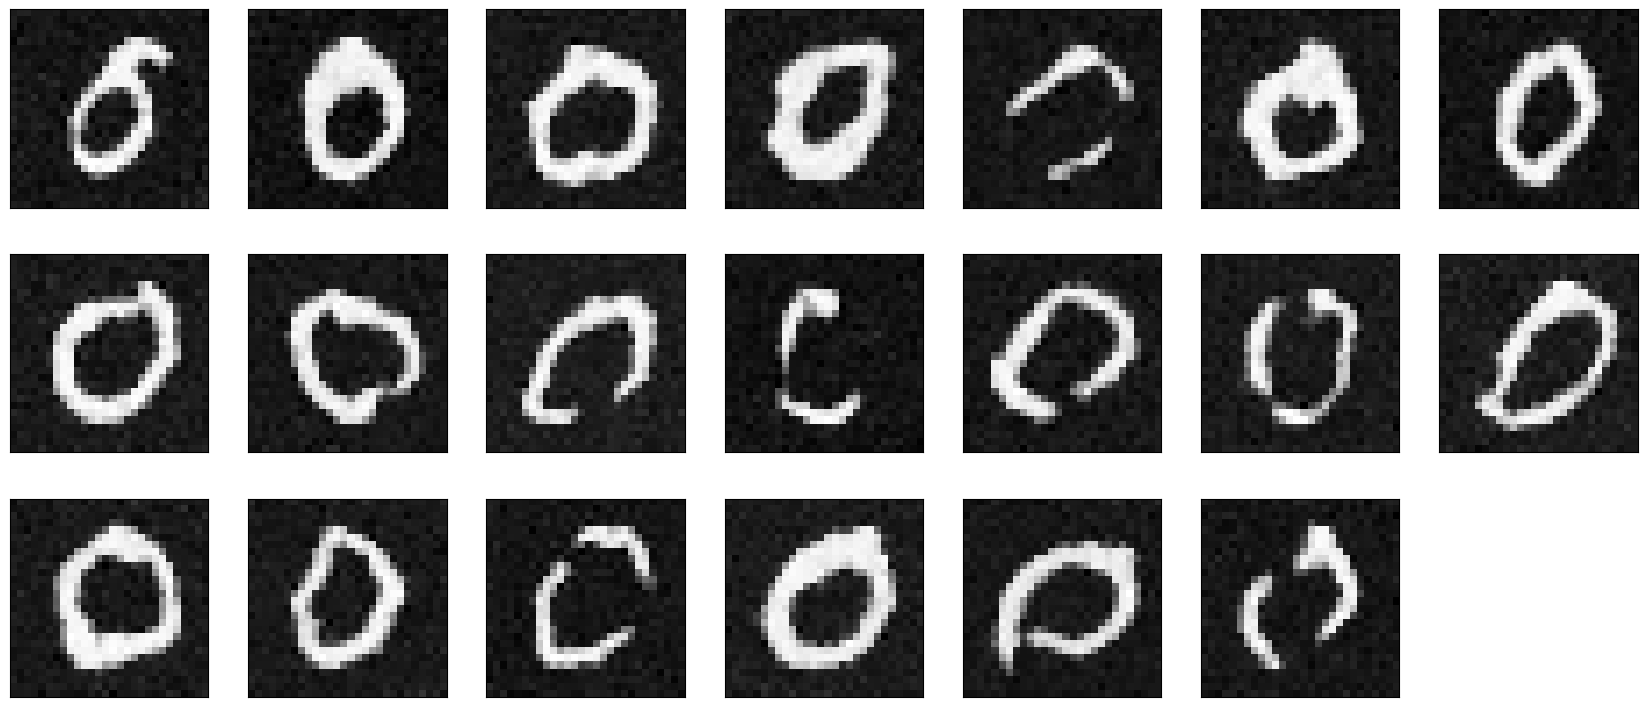

In [15]:
nrows, ncols = 3, 7
plt.figure(figsize=(3 * ncols, 3 * nrows))
for i in range(samples.shape[0]):
    plt.subplot(nrows, ncols, i + 1)
    plt.imshow(1 - samples[i].detach().cpu().numpy(), cmap="Greys")
    plt.xticks([])
    plt.yticks([])

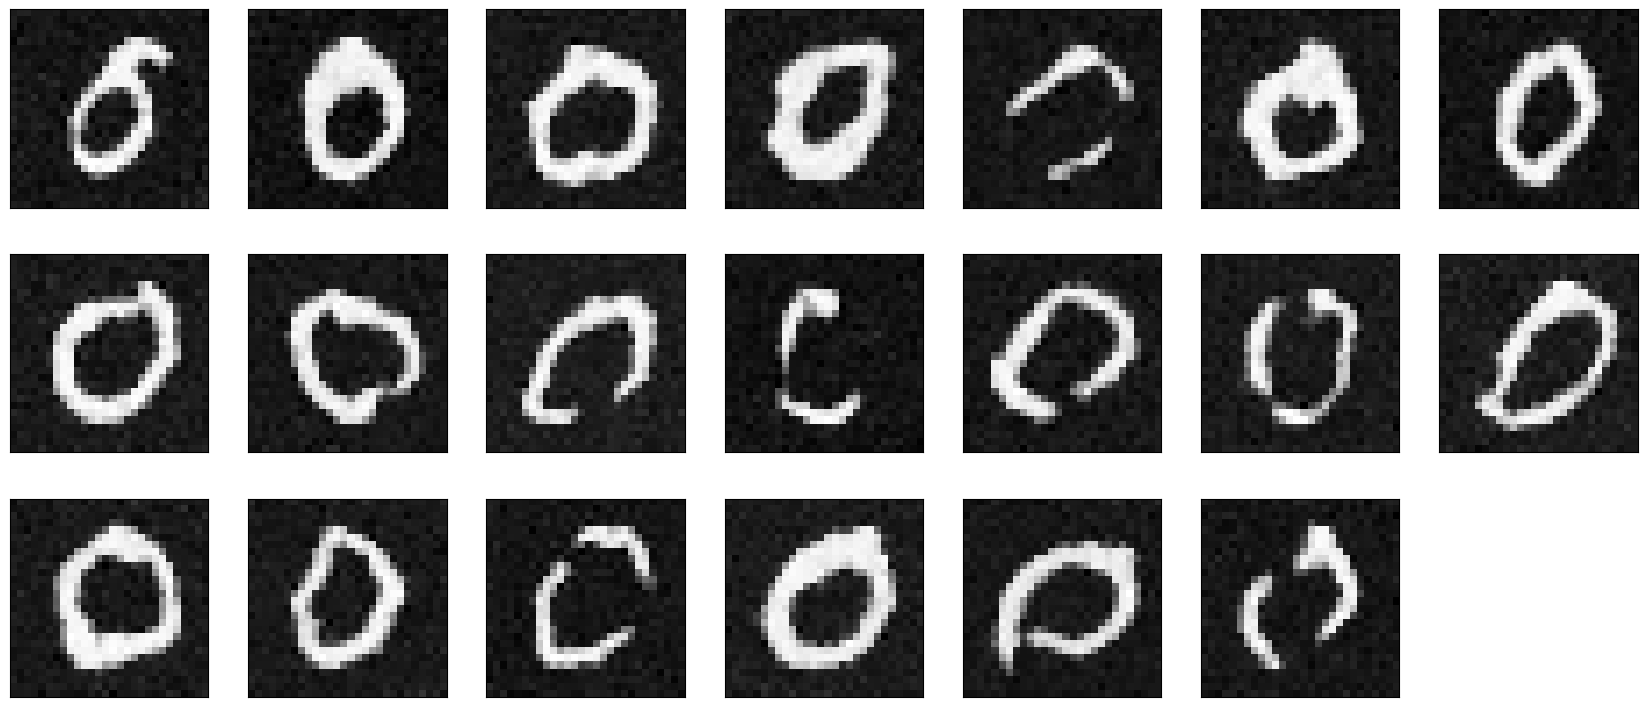

In [16]:
nrows, ncols = 3, 7
plt.figure(figsize=(3 * ncols, 3 * nrows))
for i in range(samples.shape[0]):
    plt.subplot(nrows, ncols, i + 1)
    plt.imshow(1 - samples[i].detach().cpu().numpy(), cmap="Greys")
    plt.xticks([])
    plt.yticks([])

## Anomaly Detection: Test How Well the Pipeline Differentiates Normal vs Anomalous Digits

In [17]:
# Compute anomaly scores using score norm for all test data
def compute_anomaly_scores(score_network, test_data, time_val=0.5, batch_size=128):
    """
    Compute anomaly scores for test data using score norms.
    Higher score norm = more anomalous
    """
    score_network.eval()
    device = next(score_network.parameters()).device
    
    all_scores = []
    t = torch.tensor([[time_val]], dtype=torch.float32, device=device)
    
    with torch.no_grad():
        for i in range(0, len(test_data), batch_size):
            batch = test_data[i:i+batch_size].to(device)
            scores = score_network(batch, t.expand(batch.shape[0], 1))
            score_norms = torch.norm(scores, dim=1).cpu().numpy()
            all_scores.extend(score_norms)
    
    return np.array(all_scores)

# Load all MNIST test data
print("Loading MNIST test data...")
test_dataset = torchvision.datasets.MNIST("mnist", train=False, download=True, transform=transforms)
test_data_all = test_dataset.data.reshape(len(test_dataset), -1).float() / 255.0
test_labels = test_dataset.targets.numpy()

# Compute anomaly scores
print("Computing anomaly scores...")
anomaly_scores = compute_anomaly_scores(score_network, test_data_all, time_val=0.5)

# Create binary labels: 0 = normal (digit 0), 1 = anomaly (other digits)
baseline_digit = 0
binary_labels = (test_labels != baseline_digit).astype(int)

print(f"Anomaly scores computed: min={anomaly_scores.min():.3f}, max={anomaly_scores.max():.3f}")
print(f"Normal samples (digit {baseline_digit}): {np.sum(binary_labels==0)}")
print(f"Anomalous samples (other digits): {np.sum(binary_labels==1)}")


Loading MNIST test data...
Computing anomaly scores...
Anomaly scores computed: min=3.666, max=12.680
Normal samples (digit 0): 980
Anomalous samples (other digits): 9020


In [18]:
# Per-digit analysis: how much does each digit differ from the baseline?
per_digit_stats = {}

for digit in range(10):
    mask = test_labels == digit
    digit_scores = anomaly_scores[mask]
    per_digit_stats[digit] = {
        'count': mask.sum(),
        'mean': digit_scores.mean(),
        'std': digit_scores.std(),
        'min': digit_scores.min(),
        'max': digit_scores.max(),
    }

# Print per-digit statistics
print(f"\n{'='*70}")
print(f"Per-Digit Anomaly Score Analysis")
print(f"{'='*70}")
print(f"{'Digit':<8} {'Count':<8} {'Mean':<10} {'Std':<10} {'Min':<10} {'Max':<10}")
print("-" * 70)
for digit in range(10):
    stats = per_digit_stats[digit]
    marker = " <- BASELINE" if digit == baseline_digit else ""
    print(f"{digit:<8} {stats['count']:<8} {stats['mean']:<10.3f} {stats['std']:<10.3f} {stats['min']:<10.3f} {stats['max']:<10.3f}{marker}")

# Calculate separation between baseline and each other digit
print(f"\n{'='*70}")
print(f"Separability Analysis (in units of baseline std)")
print(f"{'='*70}")
baseline_mean = per_digit_stats[baseline_digit]['mean']
baseline_std = per_digit_stats[baseline_digit]['std']

separation_dict = {}
for digit in range(10):
    if digit != baseline_digit:
        mean_diff = per_digit_stats[digit]['mean'] - baseline_mean
        separation = mean_diff / (baseline_std + 1e-6)
        separation_dict[digit] = separation
        detectability = "Easy" if separation > 2.0 else "Medium" if separation > 1.0 else "Hard"
        print(f"Digit {digit}: separation={separation:>6.2f}σ  [{detectability}]")



Per-Digit Anomaly Score Analysis
Digit    Count    Mean       Std        Min        Max       
----------------------------------------------------------------------
0        980      8.717      1.348      5.247      12.676     <- BASELINE
1        1135     6.211      0.866      3.666      9.779     
2        1032     8.670      1.104      5.281      12.680    
3        1010     8.425      1.098      4.617      11.431    
4        982      7.771      0.992      4.348      10.642    
5        892      8.009      1.124      3.991      11.029    
6        958      8.252      1.148      3.948      12.037    
7        1028     7.647      1.003      4.452      10.771    
8        974      8.523      1.020      5.219      11.799    
9        1009     7.819      0.927      4.297      11.263    

Separability Analysis (in units of baseline std)
Digit 1: separation= -1.86σ  [Hard]
Digit 2: separation= -0.03σ  [Hard]
Digit 3: separation= -0.22σ  [Hard]
Digit 4: separation= -0.70σ  [Hard]
Digit 5

/var/folders/91/j3k25b391lv5t2z7dsh5s1b00000gn/T/ipykernel_9832/3330464870.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


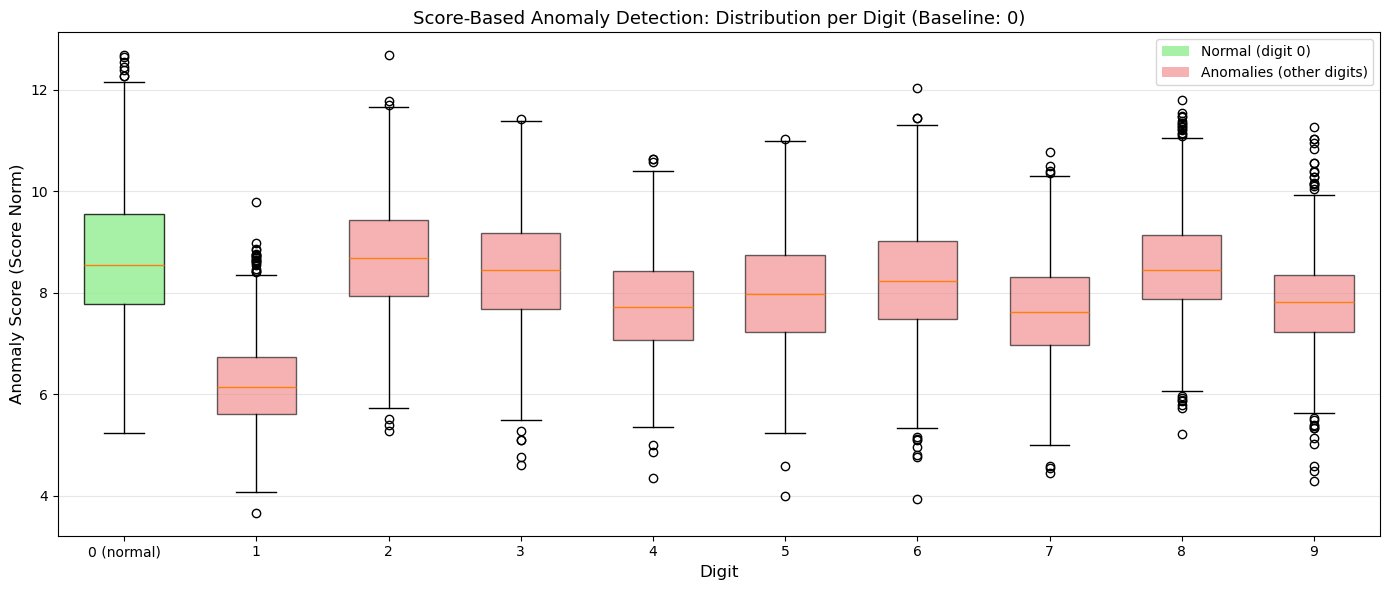

In [19]:
# Visualize anomaly score distributions per digit
from matplotlib.patches import Patch

digit_scores_by_class = [anomaly_scores[test_labels == d] for d in range(10)]

fig, ax = plt.subplots(figsize=(14, 6))

bp = ax.boxplot(
    digit_scores_by_class,
    positions=range(10),
    widths=0.6,
    patch_artist=True,
    labels=[f"{d}" + (" (normal)" if d == baseline_digit else "") for d in range(10)]
)

# Color baseline differently
for i, patch in enumerate(bp['boxes']):
    if i == baseline_digit:
        patch.set_facecolor('lightgreen')
        patch.set_alpha(0.8)
    else:
        patch.set_facecolor('lightcoral')
        patch.set_alpha(0.6)

ax.set_xlabel('Digit', fontsize=12)
ax.set_ylabel('Anomaly Score (Score Norm)', fontsize=12)
ax.set_title(f'Score-Based Anomaly Detection: Distribution per Digit (Baseline: {baseline_digit})', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')

# Add legend
legend_elements = [Patch(facecolor='lightgreen', alpha=0.8, label=f'Normal (digit {baseline_digit})'),
                   Patch(facecolor='lightcoral', alpha=0.6, label='Anomalies (other digits)')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()


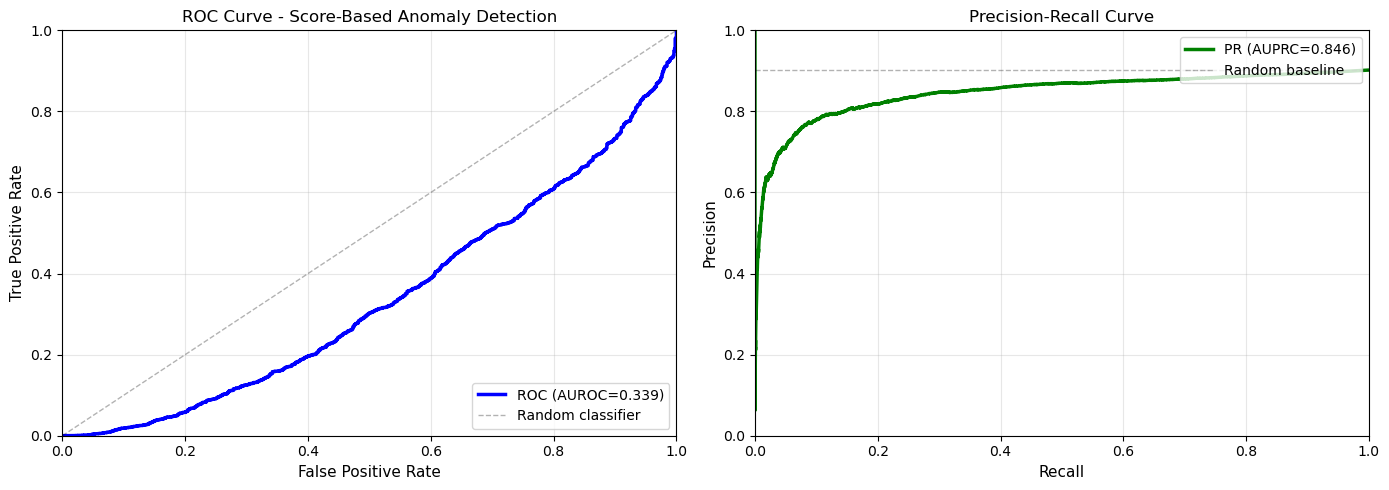


Performance Metrics:
  AUROC: 0.3394
  AUPRC: 0.8456


In [20]:
# ROC and detection performance
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve

fpr, tpr, thresholds = roc_curve(binary_labels, anomaly_scores)
roc_auc = roc_auc_score(binary_labels, anomaly_scores)
precision, recall, _ = precision_recall_curve(binary_labels, anomaly_scores)
pr_auc = auc(recall, precision)

# Plot ROC and PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
axes[0].plot(fpr, tpr, lw=2.5, label=f'ROC (AUROC={roc_auc:.3f})', color='blue')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3, label='Random classifier')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title(f'ROC Curve - Score-Based Anomaly Detection', fontsize=12)
axes[0].legend(loc='lower right', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# Precision-Recall Curve
axes[1].plot(recall, precision, lw=2.5, label=f'PR (AUPRC={pr_auc:.3f})', color='green')
axes[1].axhline(y=np.sum(binary_labels==1)/len(binary_labels), color='k', linestyle='--', lw=1, alpha=0.3, label='Random baseline')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title(f'Precision-Recall Curve', fontsize=12)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"\nPerformance Metrics:")
print(f"  AUROC: {roc_auc:.4f}")
print(f"  AUPRC: {pr_auc:.4f}")


Visual Examples: Score-Based Anomaly Detection

Normal samples (Digit 0):


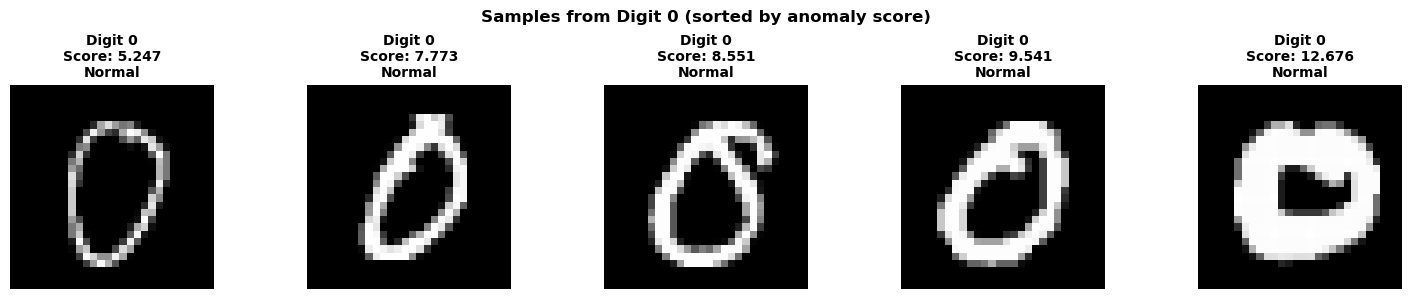


Anomalous samples (Digit 1) - Highly different from baseline:


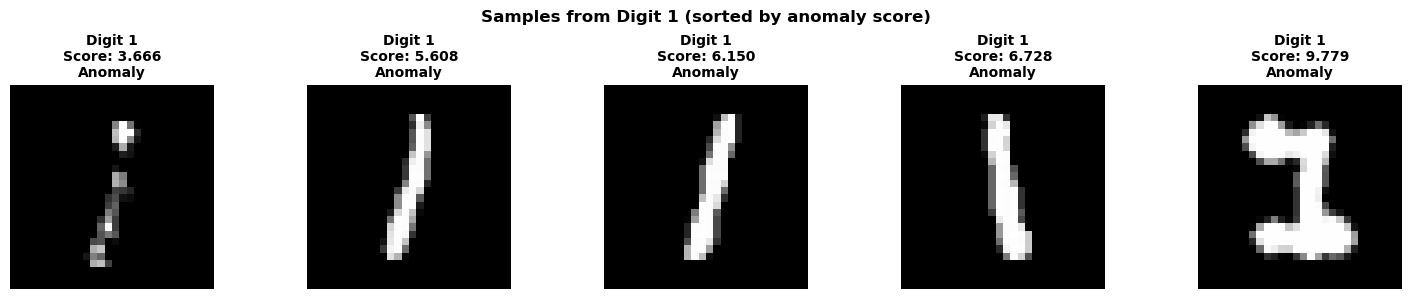


Anomalous samples (Digit 8) - Shape might be similar to baseline:


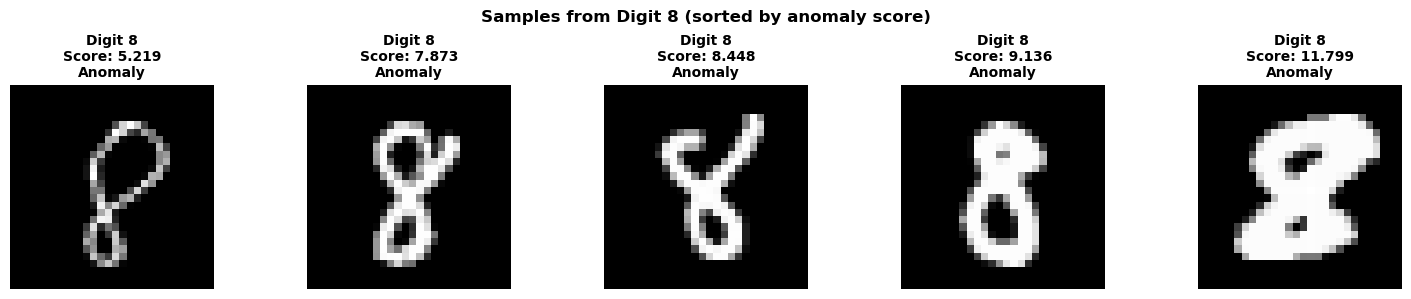

In [21]:
# Visual examples: show samples with their anomaly scores
def show_examples_by_digit(digit, num_samples=5):
    """Show samples from a digit with their anomaly scores."""
    mask = test_labels == digit
    indices = np.where(mask)[0]
    
    # Sort by anomaly score to show range
    sorted_indices = indices[np.argsort(anomaly_scores[indices])]
    
    # Select samples across the range (lowest, mid-low, mid, mid-high, highest)
    selected = sorted_indices[np.linspace(0, len(sorted_indices)-1, num_samples, dtype=int)]
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    if num_samples == 1:
        axes = [axes]
    
    for idx, ax in enumerate(axes):
        sample_idx = selected[idx]
        score = anomaly_scores[sample_idx]
        label = "Normal" if digit == baseline_digit else "Anomaly"
        
        img = test_data_all[sample_idx].view(28, 28).cpu().numpy()
        ax.imshow(img, cmap='gray')
        ax.set_title(f"Digit {digit}\nScore: {score:.3f}\n{label}", fontsize=10, fontweight='bold')
        ax.axis('off')
    
    plt.suptitle(f"Samples from Digit {digit} (sorted by anomaly score)", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Show examples from baseline and a few other digits
print("="*60)
print("Visual Examples: Score-Based Anomaly Detection")
print("="*60)

print(f"\nNormal samples (Digit {baseline_digit}):")
show_examples_by_digit(baseline_digit, num_samples=5)

print(f"\nAnomalous samples (Digit 1) - Highly different from baseline:")
show_examples_by_digit(1, num_samples=5)

print(f"\nAnomalous samples (Digit 8) - Shape might be similar to baseline:")
show_examples_by_digit(8, num_samples=5)


In [22]:
# Detection thresholds and operating points
def compute_detection_metrics(scores, labels, threshold):
    """Compute TP, FP, TN, FN at a given threshold."""
    predictions = (scores > threshold).astype(int)
    
    tp = ((predictions == 1) & (labels == 1)).sum()
    fp = ((predictions == 1) & (labels == 0)).sum()
    tn = ((predictions == 0) & (labels == 0)).sum()
    fn = ((predictions == 0) & (labels == 1)).sum()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    return {'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn, 'TPR': tpr, 'FPR': fpr, 'TNR': tnr, 'Precision': precision}

# Test at different thresholds
percentiles = [50, 75, 90, 95, 99]
thresholds = np.percentile(anomaly_scores, percentiles)

print(f"\n{'='*80}")
print(f"Detection Performance at Different Thresholds")
print(f"{'='*80}")
print(f"{'Threshold':<12} {'Percentile':<12} {'TPR':<10} {'TNR':<10} {'Precision':<12} {'Flagged':<10}")
print("-" * 80)

for threshold, pct in zip(thresholds, percentiles):
    metrics = compute_detection_metrics(anomaly_scores, binary_labels, threshold)
    flagged = np.sum(anomaly_scores > threshold) / len(anomaly_scores) * 100
    print(f"{threshold:<12.3f} {pct:<12}% {metrics['TPR']:<10.3f} {metrics['TNR']:<10.3f} {metrics['Precision']:<12.3f} {flagged:<10.1f}%")

# Optimal threshold (Youden's J statistic = TPR + TNR - 1)
j_scores = []
threshold_range = np.percentile(anomaly_scores, np.linspace(1, 99, 200))

for threshold in threshold_range:
    metrics = compute_detection_metrics(anomaly_scores, binary_labels, threshold)
    j = metrics['TPR'] + metrics['TNR'] - 1
    j_scores.append(j)

optimal_idx = np.argmax(j_scores)
optimal_threshold = threshold_range[optimal_idx]
optimal_metrics = compute_detection_metrics(anomaly_scores, binary_labels, optimal_threshold)

print(f"\n{'='*80}")
print(f"Optimal Operating Point (Youden's J = TPR + TNR - 1)")
print(f"{'='*80}")
print(f"Optimal threshold: {optimal_threshold:.3f}")
print(f"  True Positive Rate (detect anomalies): {optimal_metrics['TPR']:.4f}")
print(f"  True Negative Rate (correctly identify normal): {optimal_metrics['TNR']:.4f}")
print(f"  False Positive Rate (false alarms): {optimal_metrics['FPR']:.4f}")
print(f"  Precision: {optimal_metrics['Precision']:.4f}")
print(f"  Youden's J: {optimal_metrics['TPR'] + optimal_metrics['TNR'] - 1:.4f}")



Detection Performance at Different Thresholds
Threshold    Percentile   TPR        TNR        Precision    Flagged   
--------------------------------------------------------------------------------
7.983        50          % 0.481      0.329      0.868        50.0      %
8.828        75          % 0.229      0.559      0.827        25.0      %
9.603        90          % 0.085      0.765      0.770        10.0      %
10.082       95          % 0.039      0.846      0.698        5.0       %
11.154       99          % 0.005      0.943      0.440        1.0       %

Optimal Operating Point (Youden's J = TPR + TNR - 1)
Optimal threshold: 5.051
  True Positive Rate (detect anomalies): 0.9889
  True Negative Rate (correctly identify normal): 0.0000
  False Positive Rate (false alarms): 1.0000
  Precision: 0.9010
  Youden's J: -0.0111


In [24]:
# Comprehensive analysis: Iterate through all digits 0-9 as baseline
import pandas as pd
from sklearn.metrics import roc_auc_score, auc, roc_curve, precision_recall_curve
import time

# Retraining configuration
RETRAIN_EPOCHS = 50  # change this as needed (higher -> better but slower)
RETRAIN_BATCH_SIZE = 64
RETRAIN_LR = 3e-4
CHECKPOINT_DIR = 'score_checkpoints'

import os
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("="*80)
print("SGM-SDE Anomaly Detection: Comprehensive Analysis with Retraining (Baseline 0-9)")
print("="*80)

# Store results for all baseline digits
all_results = []

# Load test data once
print("\nLoading MNIST test data...")
test_dataset = torchvision.datasets.MNIST("mnist", train=False, download=True, transform=transforms)
test_data_all = test_dataset.data.reshape(len(test_dataset), -1).float() / 255.0
test_labels = test_dataset.targets.numpy()

# Iterate through each digit as baseline
for baseline_digit in range(10):
    print(f"\n[{baseline_digit}/9] Processing baseline digit {baseline_digit}...")

    # Prepare training data for this baseline digit (use training split)
    train_targets = mnist_dset.targets
    train_idx = (train_targets == baseline_digit).nonzero(as_tuple=True)[0]
    train_subset = Subset(mnist_dset, train_idx)
    train_loader = torch.utils.data.DataLoader(train_subset, batch_size=RETRAIN_BATCH_SIZE, shuffle=True)

    # Initialize network and optimizer
    model = ScoreNetwork0()

    # Move to device (use same device as earlier code)
    if torch.cuda.is_available():
        dev = torch.device('cuda:0')
    else:
        dev = torch.device('cpu')
    model = model.to(dev)
    optimizer = torch.optim.Adam(model.parameters(), lr=RETRAIN_LR)

    # Retrain the network for this baseline digit
    print(f"  Training model for digit {baseline_digit} ({RETRAIN_EPOCHS} epochs) on device: {dev}")
    t_start = time.time()
    for epoch in range(1, RETRAIN_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        n_seen = 0
        for batch, _ in train_loader:
            batch = batch.reshape(batch.shape[0], -1).to(dev)
            optimizer.zero_grad()
            loss = calc_loss(model, batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.detach().item() * batch.shape[0]
            n_seen += batch.shape[0]
        if epoch % 10 == 0 or epoch == 1 or epoch == RETRAIN_EPOCHS:
            avg_loss = running_loss / (n_seen + 1e-12)
            print(f"    Epoch {epoch}/{RETRAIN_EPOCHS}  AvgLoss={avg_loss:.6f}")
    print(f"  Training finished in {time.time() - t_start:.1f}s")

    # Save checkpoint
    ckpt_path = os.path.join(CHECKPOINT_DIR, f"score_checkpoint_digit_{baseline_digit}.pt")
    torch.save(model.state_dict(), ckpt_path)
    print(f"  Saved checkpoint: {ckpt_path}")

    # Compute anomaly scores with this model
    anomaly_scores_local = compute_anomaly_scores(model, test_data_all, time_val=0.5)
    binary_labels_local = (test_labels != baseline_digit).astype(int)

    # Per-digit statistics
    per_digit_stats = {}
    for digit in range(10):
        mask = test_labels == digit
        digit_scores = anomaly_scores_local[mask]
        per_digit_stats[digit] = {
            'count': mask.sum(),
            'mean': float(digit_scores.mean()),
            'std': float(digit_scores.std()),
            'min': float(digit_scores.min()),
            'max': float(digit_scores.max()),
        }

    # Calculate metrics for this baseline
    fpr, tpr, _ = roc_curve(binary_labels_local, anomaly_scores_local)
    roc_auc = float(roc_auc_score(binary_labels_local, anomaly_scores_local))
    precision, recall, _ = precision_recall_curve(binary_labels_local, anomaly_scores_local)
    pr_auc = float(auc(recall, precision))

    # Optimal threshold (Youden's J)
    j_scores = []
    threshold_range = np.percentile(anomaly_scores_local, np.linspace(1, 99, 100))
    for threshold in threshold_range:
        metrics = compute_detection_metrics(anomaly_scores_local, binary_labels_local, threshold)
        j = metrics['TPR'] + metrics['TNR'] - 1
        j_scores.append(j)
    optimal_idx = np.argmax(j_scores)
    optimal_threshold = float(threshold_range[optimal_idx])
    optimal_metrics = compute_detection_metrics(anomaly_scores_local, binary_labels_local, optimal_threshold)

    # Store results
    for digit in range(10):
        stats = per_digit_stats[digit]
        result = {
            'Baseline_Digit': int(baseline_digit),
            'Test_Digit': int(digit),
            'Baseline_Type': 'Normal' if digit == baseline_digit else 'Anomaly',
            'Sample_Count': int(stats['count']),
            'Mean_Score': stats['mean'],
            'Std_Score': stats['std'],
            'Min_Score': stats['min'],
            'Max_Score': stats['max'],
        }
        # Add baseline-level metrics only once per baseline
        if digit == 0:
            result.update({
                'AUROC': roc_auc,
                'AUPRC': pr_auc,
                'Optimal_Threshold': optimal_threshold,
                'Optimal_TPR': optimal_metrics['TPR'],
                'Optimal_TNR': optimal_metrics['TNR'],
                'Optimal_FPR': optimal_metrics['FPR'],
                'Optimal_Precision': optimal_metrics['Precision']
            })
        all_results.append(result)

    print(f"  ✓ AUROC: {roc_auc:.4f}, AUPRC: {pr_auc:.4f}")

# Create DataFrame
results_df = pd.DataFrame(all_results)

# Save to Excel
output_file = 'SGM_SDE_result.xlsx'
results_df.to_excel(output_file, index=False, sheet_name='Results')

print(f"\n{'='*80}")
print(f"✓ Results saved to: {output_file}")
print(f"  Total records: {len(results_df)}")
print(f"  Baseline digits: 0-9")
print(f"  Test digits per baseline: 0-9")
print(f"{'='*80}")

# Display summary
print("\nSummary Table (AUROC per baseline digit):")
summary_df = results_df[results_df['Test_Digit'] == 0][['Baseline_Digit', 'AUROC', 'AUPRC', 'Optimal_TPR', 'Optimal_TNR']].copy()
print(summary_df.to_string(index=False))


SGM-SDE Anomaly Detection: Comprehensive Analysis with Retraining (Baseline 0-9)

Loading MNIST test data...

[0/9] Processing baseline digit 0...
  Training model for digit 0 (50 epochs) on device: cpu


KeyboardInterrupt: 